In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import os

print(os.getcwd())

e:\python\basics\code\OnlineRetailAnalysis\notebooks


In [7]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")


print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [13]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [14]:
df = df.drop_duplicates()

In [15]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [18]:
df['Month'] = df['InvoiceDate'].dt.month_name()

In [19]:
df['Sales'].sum()


np.float64(8887208.894000001)

In [20]:
df['InvoiceNo'].nunique()

18532

In [21]:
df['CustomerID'].nunique()

4338

In [22]:
df.groupby('InvoiceNo')['Sales'].sum().mean()

np.float64(479.56016047917126)

In [23]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

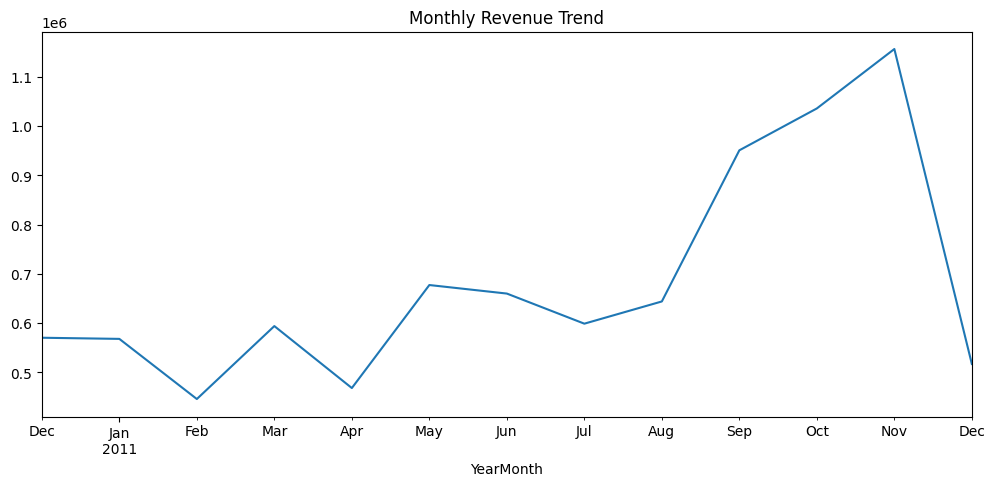

In [24]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.show()

In [25]:
top_products = (
    df.groupby('Description')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

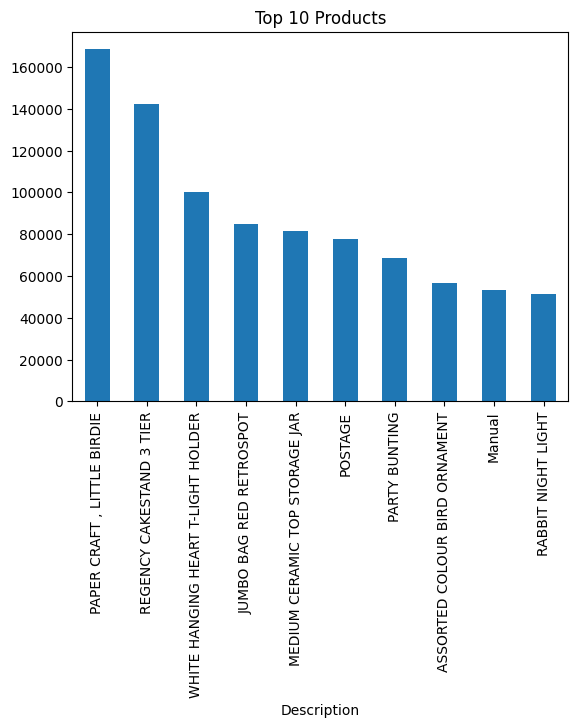

In [26]:
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [35]:
country_sales = (
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

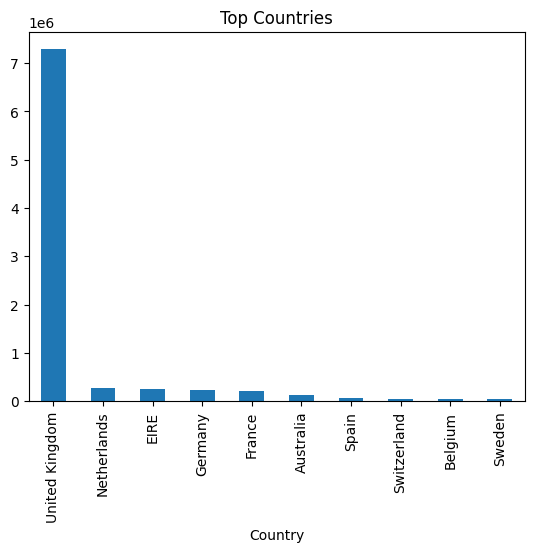

In [28]:
country_sales.plot(kind='bar')
plt.title("Top Countries")
plt.show()

In [29]:
top_customers = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

In [33]:
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64

In [34]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [31]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

In [32]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05
